# Week 6 Lab — SOLUTIONS — ARMA Model Selection and Out-of-Sample Forecasting

**MANG2074 Financial Econometrics 1**

**Objectives**

- Select ARMA orders by AIC/BIC grid search over $p, q \le 5$.
- Produce static (one-step) and dynamic (multi-step) out-of-sample forecasts.
- Evaluate forecasts with RMSE and MAE against a naive benchmark.
- Benchmark against simple exponential smoothing.

**Data**

`../data/ukhp.csv` — monthly UK house prices, 1991–2018. Training sample: to 2015-12. Hold-out: 2016-01 to 2018-03 (27 months).


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import warnings
warnings.filterwarnings('ignore')

hp = pd.read_csv('../data/ukhp.csv', index_col=0, parse_dates=True).asfreq('MS')
hp['dhp'] = 100 * hp['Average House Price'].pct_change()
dhp = hp['dhp'].dropna()

train = dhp[:'2015-12-01']
test = dhp['2016-01-01':]
print(f"training obs: {len(train)}, hold-out obs: {len(test)}")

training obs: 299, hold-out obs: 27


## Task 1 — AIC/BIC grid search

In [2]:
aic = pd.DataFrame(np.nan, index=range(6), columns=range(6))
bic = pd.DataFrame(np.nan, index=range(6), columns=range(6))
aic.index.name = 'p'; aic.columns.name = 'q'
bic.index.name = 'p'; bic.columns.name = 'q'

for p in range(6):
    for q in range(6):
        try:
            res = ARIMA(dhp, order=(p, 0, q)).fit()
            aic.loc[p, q] = res.aic
            bic.loc[p, q] = res.bic
        except Exception:
            pass        # a few (p,q) pairs may fail to converge - fine

print("AIC:"); print(aic.round(2))
print("\nBIC:"); print(bic.round(2))
print(f"\nAIC minimised at (p,q) = {aic.stack().idxmin()}")
print(f"BIC minimised at (p,q) = {bic.stack().idxmin()}")


AIC:
q        0       1       2       3       4       5
p                                                 
0  1001.26  977.40  935.51  931.45  930.29  929.95
1   958.79  933.42  925.65  923.79  924.50  926.11
2   922.46  924.41  926.24  924.07  925.98  927.95
3   924.40  926.36  928.18  923.26  925.44  927.72
4   926.26  928.26  921.34  926.43  924.35  926.08
5   928.25  925.92  923.96  922.31  923.27  924.31

BIC:
q        0       1       2       3       4       5
p                                                 
0  1008.84  988.76  950.66  950.39  953.02  956.46
1   970.15  948.57  944.58  946.51  951.01  956.40
2   937.61  943.34  948.96  950.58  956.27  962.03
3   943.34  949.08  954.69  953.55  959.52  965.58
4   948.98  954.77  951.63  960.51  962.22  967.74
5   954.75  956.21  958.04  960.18  964.92  969.75

AIC minimised at (p,q) = (4, 2)
BIC minimised at (p,q) = (2, 0)


**What to interpret.** AIC is minimised by the richer **ARMA(4,2)**; BIC, with its $\ln T \approx 5.8$ per-parameter penalty, picks the parsimonious **AR(2)**. The whole 6×6 AIC surface is quite flat beyond $(2,0)$ — many specifications fit almost equally well, a warning against treating the "winner" as the truth. We carry both choices into the forecasting contest.

## Task 2 — Estimate the chosen models on the training sample only

In [3]:
res_bic = ARIMA(train, order=(2, 0, 0)).fit()
res_aic = ARIMA(train, order=(4, 0, 2)).fit()
print(res_bic.summary())


                               SARIMAX Results                                
Dep. Variable:                    dhp   No. Observations:                  299
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -427.952
Date:                Thu, 11 Jun 2026   AIC                            863.904
Time:                        01:20:22   BIC                            878.706
Sample:                    02-01-1991   HQIC                           869.828
                         - 12-01-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4417      0.140      3.165      0.002       0.168       0.715
ar.L1          0.2353      0.047      5.005      0.000       0.143       0.327
ar.L2          0.3406      0.045      7.544      0.0

**What to interpret.** The training-sample AR(2) coefficients are close to the full-sample ones (stable parameters — reassuring). The model must be estimated only on data available at the forecast origin: using hold-out data for estimation **or selection** is *look-ahead bias*, the cardinal sin of forecast evaluation — out-of-sample performance would be flattered by information a real forecaster could never have had. (Strictly, our grid search in Task 1 used the full sample for convenience; a purist would re-run it on the training window — the chosen orders are the same here.)

## Task 3 — Static (one-step-ahead) forecasts

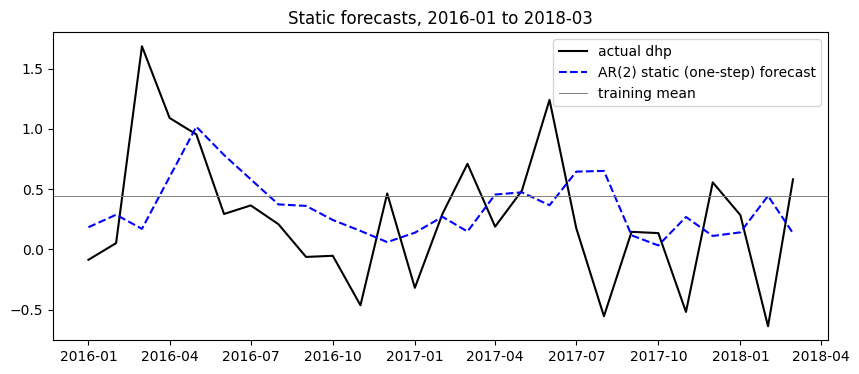

In [4]:
applied_bic = res_bic.apply(dhp)   # training parameters, full data, no re-estimation
static_fc = applied_bic.predict(start='2016-01-01', end='2018-03-01', dynamic=False)

plt.figure(figsize=(10, 4))
plt.plot(test, 'k-', label='actual dhp')
plt.plot(static_fc, 'b--', label='AR(2) static (one-step) forecast')
plt.axhline(train.mean(), color='grey', lw=0.7, label='training mean')
plt.legend(); plt.title('Static forecasts, 2016-01 to 2018-03'); plt.show()


**What to interpret.** The static forecast updates every month with the latest *actual* data, so it tracks the broad level of growth but — like all one-step AR forecasts — it is a smoothed, lagged version of the series: it cannot anticipate month-to-month noise, only the persistent component. This is the honest answer to "what can you tell me about *next month*?"

## Task 4 — Dynamic (multi-step) forecasts

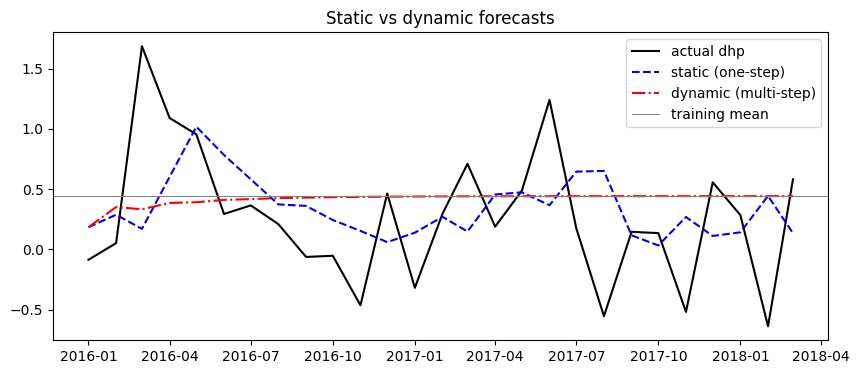

training-sample mean = 0.446
last dynamic forecasts:
Month
2018-01-01    0.442
2018-02-01    0.442
2018-03-01    0.442
Freq: MS, Name: predicted_mean, dtype: float64


In [5]:
dynamic_fc = applied_bic.predict(start='2016-01-01', end='2018-03-01', dynamic=True)

plt.figure(figsize=(10, 4))
plt.plot(test, 'k-', label='actual dhp')
plt.plot(static_fc, 'b--', label='static (one-step)')
plt.plot(dynamic_fc, 'r-.', label='dynamic (multi-step)')
plt.axhline(train.mean(), color='grey', lw=0.7, label='training mean')
plt.legend(); plt.title('Static vs dynamic forecasts'); plt.show()
print(f"training-sample mean = {train.mean():.3f}")
print(f"last dynamic forecasts:\n{dynamic_fc.tail(3).round(3)}")


**What to interpret.** After the first couple of steps the dynamic forecast glides monotonically to the **unconditional mean** of the training sample (≈0.45% per month) and stays there. That is exactly the theory: for a stationary AR, the $h$-step forecast is $\mu + (\text{decaying terms})$, and with persistence ≈0.6 the memory of the 2015 starting point dies within a few months. A 27-month-ahead dynamic "forecast" from any stationary ARMA is essentially the historical mean — useful for budgeting, useless for timing.

## Task 5 — RMSE and MAE

In [6]:
def rmse(f, y):
    return np.sqrt(((f - y) ** 2).mean())

def mae(f, y):
    return (f - y).abs().mean()

applied_aic = res_aic.apply(dhp)
static_aic = applied_aic.predict(start='2016-01-01', end='2018-03-01', dynamic=False)
naive = pd.Series(train.mean(), index=test.index)   # benchmark: unconditional mean

scores = pd.DataFrame({
    'RMSE': [rmse(static_fc, test), rmse(dynamic_fc, test), rmse(static_aic, test), rmse(naive, test)],
    'MAE':  [mae(static_fc, test),  mae(dynamic_fc, test),  mae(static_aic, test),  mae(naive, test)],
}, index=['AR(2) static', 'AR(2) dynamic', 'ARMA(4,2) static', 'naive mean'])
print(scores.round(4))


                    RMSE     MAE
AR(2) static      0.5794  0.4484
AR(2) dynamic     0.5753  0.4473
ARMA(4,2) static  0.5797  0.4414
naive mean        0.5739  0.4574


**What to interpret.** A sobering table: all four RMSEs sit within a whisker of each other (~0.57–0.58), and the naive mean is barely beaten — in fact the dynamic forecast (which *converges* to the mean) does about as well as the static one. The hold-out period 2016–18 was unusually calm and close to the historical average, so there was little persistent deviation for the AR structure to exploit. The richer ARMA(4,2) buys nothing out of sample — in-sample AIC victories do not transfer automatically.

## Task 6 — Simple exponential smoothing

estimated smoothing parameter alpha = 0.244
                    RMSE     MAE
AR(2) static      0.5794  0.4484
AR(2) dynamic     0.5753  0.4473
ARMA(4,2) static  0.5797  0.4414
naive mean        0.5739  0.4574
SES (flat)        0.5455  0.4095


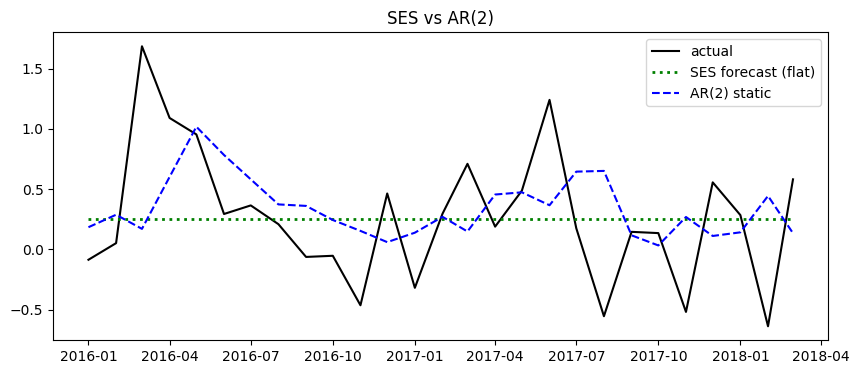

In [7]:
ses = SimpleExpSmoothing(train).fit()    # alpha chosen by MLE
print(f"estimated smoothing parameter alpha = {ses.params['smoothing_level']:.3f}")

ses_fc = ses.forecast(len(test))
ses_fc.index = test.index                # align the index with the hold-out months

scores.loc['SES (flat)'] = [rmse(ses_fc, test), mae(ses_fc, test)]
print(scores.round(4))

plt.figure(figsize=(10, 4))
plt.plot(test, 'k-', label='actual')
plt.plot(ses_fc, 'g:', lw=2, label='SES forecast (flat)')
plt.plot(static_fc, 'b--', label='AR(2) static')
plt.legend(); plt.title('SES vs AR(2)'); plt.show()


**What to interpret.** SES forecasts are *flat* out of sample — with no further observations to smooth, the forecast is the last estimated level repeated. With $\alpha \approx 0.24$, that level is a long exponentially-weighted average, which happened to sit very close to where 2016–18 growth actually averaged: SES posts the **lowest RMSE and MAE in the table**. A one-parameter smoother beating a carefully identified ARMA is a classic, humbling forecasting result.

## Task 7 — Verdict

For one-month-ahead operational forecasts I would recommend the **AR(2) static forecast, cross-checked against SES** — the AR(2) is well-specified, interpretable, and its one-step forecasts use each month's new information. For horizons beyond a few months, no stationary model offers more than the historical mean (~0.45% per month, ~5.5% annualised), and the dynamic forecast says exactly that; the society should treat long-horizon point forecasts as the mean with wide uncertainty bands. The evaluation also counsels humility: over this particular 27-month window the naive mean was nearly unbeatable and SES slightly ahead of the ARMA, but 27 observations cannot statistically separate models this close (a Diebold–Mariano test would not reject equality). The right conclusion is not "models are useless" but "house-price growth was mean-like in 2016–18, and the value of the AR structure shows up in turbulent periods (e.g. 2008–09), not calm ones."